In [1]:
import cv2
from ultralytics import YOLO
import supervision as sv

model = YOLO('yolov8n.pt')

box_annotator = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator(text_thickness=2, text_scale=0.7)

def process_traffic():
    cap = cv2.VideoCapture("data/traffic_footage.mp4")
    
    if not cap.isOpened():
        print("Error: Could not open video file. Check the path in the 'data' folder.")
        return
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        results = model(
            frame, 
            classes=[2, 3, 5, 7], 
            conf=0.7,         # Ignore low-confidence noise like manholes
            iou=0.5,          # Merge multiple boxes on the same vehicle
            agnostic_nms=True # Prevent overlapping labels for the same object
        )[0]
        
        detections = sv.Detections.from_ultralytics(results)
        
        labels = [
            f"{model.model.names[class_id]} {confidence:0.2f}"
            for class_id, confidence 
            in zip(detections.class_id, detections.confidence)
        ]

        annotated_frame = box_annotator.annotate(
            scene=frame, 
            detections=detections
        )
        annotated_frame = label_annotator.annotate(
            scene=annotated_frame, 
            detections=detections, 
            labels=labels
        )

        cv2.imshow("Urban Traffic Vision", annotated_frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    process_traffic()


0: 384x640 2 cars, 60.7ms
Speed: 24.2ms preprocess, 60.7ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 43.7ms
Speed: 4.4ms preprocess, 43.7ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 39.7ms
Speed: 2.8ms preprocess, 39.7ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 38.1ms
Speed: 3.0ms preprocess, 38.1ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 40.9ms
Speed: 2.2ms preprocess, 40.9ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 37.7ms
Speed: 2.2ms preprocess, 37.7ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 36.5ms
Speed: 2.3ms preprocess, 36.5ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 40.8ms
Speed: 2.2ms preprocess, 40.8ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)


Speed: 1.7ms preprocess, 32.9ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 36.3ms
Speed: 2.5ms preprocess, 36.3ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 32.5ms
Speed: 1.8ms preprocess, 32.5ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 34.2ms
Speed: 1.7ms preprocess, 34.2ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 36.0ms
Speed: 3.9ms preprocess, 36.0ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 30.7ms
Speed: 2.0ms preprocess, 30.7ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 42.8ms
Speed: 2.1ms preprocess, 42.8ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 35.4ms
Speed: 1.7ms preprocess, 35.4ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 3


0: 384x640 (no detections), 42.0ms
Speed: 1.7ms preprocess, 42.0ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 39.1ms
Speed: 2.4ms preprocess, 39.1ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 39.7ms
Speed: 2.1ms preprocess, 39.7ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 48.6ms
Speed: 3.9ms preprocess, 48.6ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 40.2ms
Speed: 2.5ms preprocess, 40.2ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 31.6ms
Speed: 1.7ms preprocess, 31.6ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 34.8ms
Speed: 1.9ms preprocess, 34.8ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 37.3ms
Speed: 2.1ms preprocess, 37.3ms inference, 0.9ms postprocess p


0: 384x640 1 car, 39.3ms
Speed: 2.1ms preprocess, 39.3ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 33.8ms
Speed: 3.5ms preprocess, 33.8ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 35.3ms
Speed: 1.8ms preprocess, 35.3ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 33.3ms
Speed: 2.6ms preprocess, 33.3ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 33.4ms
Speed: 3.2ms preprocess, 33.4ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 34.2ms
Speed: 1.7ms preprocess, 34.2ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 33.6ms
Speed: 2.0ms preprocess, 33.6ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 37.1ms
Speed: 3.4ms preprocess, 37.1ms inference, 1.0ms postprocess per image at shape (1, 3, 38

Speed: 1.9ms preprocess, 29.2ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 36.6ms
Speed: 1.8ms preprocess, 36.6ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 30.5ms
Speed: 2.0ms preprocess, 30.5ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 34.5ms
Speed: 1.7ms preprocess, 34.5ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 37.8ms
Speed: 1.7ms preprocess, 37.8ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 33.9ms
Speed: 1.8ms preprocess, 33.9ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 36.0ms
Speed: 1.8ms preprocess, 36.0ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 34.0ms
Speed: 1.7ms preprocess, 34.0ms inference, 0.7ms postprocess per image at shape

...


0: 384x640 (no detections), 31.3ms
Speed: 1.9ms preprocess, 31.3ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 33.7ms
Speed: 1.9ms preprocess, 33.7ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 34.1ms
Speed: 1.9ms preprocess, 34.1ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 40.8ms
Speed: 2.0ms preprocess, 40.8ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 34.3ms
Speed: 1.9ms preprocess, 34.3ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 35.1ms
Speed: 1.9ms preprocess, 35.1ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 36.9ms
Speed: 3.2ms preprocess, 36.9ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 38.9ms
Speed: 2.8ms preprocess, 38.9ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)


0: 384x640 1 car, 1 truck, 39.5ms
Speed: 3.2ms preprocess, 39.5ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 truck, 41.0ms
Speed: 2.2ms preprocess, 41.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 truck, 37.9ms
Speed: 2.0ms preprocess, 37.9ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 37.6ms
Speed: 2.3ms preprocess, 37.6ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 38.2ms
Speed: 2.2ms preprocess, 38.2ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 36.2ms
Speed: 2.6ms preprocess, 36.2ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 37.7ms
Speed: 2.3ms preprocess, 37.7ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 1 truck, 41.1ms
Speed: 2.5ms preprocess, 41.1ms infer


0: 384x640 1 car, 33.2ms
Speed: 2.5ms preprocess, 33.2ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 36.0ms
Speed: 2.6ms preprocess, 36.0ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 35.0ms
Speed: 2.0ms preprocess, 35.0ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 37.1ms
Speed: 4.0ms preprocess, 37.1ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 37.4ms
Speed: 4.0ms preprocess, 37.4ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 38.8ms
Speed: 2.2ms preprocess, 38.8ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 40.0ms
Speed: 2.4ms preprocess, 40.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 cars, 36.9ms
Speed: 2.3ms preprocess, 36.9ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x6


0: 384x640 3 cars, 44.1ms
Speed: 2.8ms preprocess, 44.1ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 39.3ms
Speed: 5.0ms preprocess, 39.3ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 cars, 46.5ms
Speed: 2.2ms preprocess, 46.5ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 40.1ms
Speed: 2.9ms preprocess, 40.1ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 37.9ms
Speed: 2.3ms preprocess, 37.9ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 36.3ms
Speed: 3.2ms preprocess, 36.3ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 39.4ms
Speed: 3.6ms preprocess, 39.4ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 cars, 40.6ms
Speed: 2.4ms preprocess, 40.6ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x6

Speed: 4.5ms preprocess, 43.5ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 46.5ms
Speed: 2.3ms preprocess, 46.5ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 42.2ms
Speed: 4.3ms preprocess, 42.2ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 47.9ms
Speed: 2.1ms preprocess, 47.9ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 42.8ms
Speed: 2.4ms preprocess, 42.8ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 42.1ms
Speed: 3.4ms preprocess, 42.1ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 41.4ms
Speed: 2.0ms preprocess, 41.4ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 40.5ms
Speed: 2.6ms preprocess, 40.5ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 45.9ms
Speed: 2.5ms 


0: 384x640 4 cars, 1 bus, 33.5ms
Speed: 18.4ms preprocess, 33.5ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 36.8ms
Speed: 4.5ms preprocess, 36.8ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 cars, 34.0ms
Speed: 3.5ms preprocess, 34.0ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 cars, 43.5ms
Speed: 3.7ms preprocess, 43.5ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 cars, 1 bus, 30.9ms
Speed: 2.9ms preprocess, 30.9ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 cars, 1 bus, 32.2ms
Speed: 1.6ms preprocess, 32.2ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 cars, 1 bus, 30.5ms
Speed: 1.7ms preprocess, 30.5ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 cars, 1 bus, 34.4ms
Speed: 1.9ms preprocess, 34.4ms inference, 1.0ms postprocess per imag


0: 384x640 5 cars, 34.6ms
Speed: 1.8ms preprocess, 34.6ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 cars, 26.9ms
Speed: 2.0ms preprocess, 26.9ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 cars, 31.1ms
Speed: 1.7ms preprocess, 31.1ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 cars, 33.4ms
Speed: 1.7ms preprocess, 33.4ms inference, 2.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 cars, 32.3ms
Speed: 1.9ms preprocess, 32.3ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 cars, 30.9ms
Speed: 1.7ms preprocess, 30.9ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 cars, 31.9ms
Speed: 1.7ms preprocess, 31.9ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 cars, 28.0ms
Speed: 1.6ms preprocess, 28.0ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x


0: 384x640 4 cars, 29.9ms
Speed: 1.8ms preprocess, 29.9ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 33.5ms
Speed: 1.7ms preprocess, 33.5ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 24.8ms
Speed: 1.6ms preprocess, 24.8ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 27.0ms
Speed: 2.5ms preprocess, 27.0ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 30.7ms
Speed: 1.7ms preprocess, 30.7ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 30.3ms
Speed: 1.8ms preprocess, 30.3ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 31.5ms
Speed: 2.1ms preprocess, 31.5ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 28.2ms
Speed: 2.1ms preprocess, 28.2ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)


0: 384x640 6 cars, 26.9ms
Speed: 2.0ms preprocess, 26.9ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 7 cars, 26.3ms
Speed: 2.4ms preprocess, 26.3ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 cars, 30.8ms
Speed: 1.8ms preprocess, 30.8ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 cars, 31.9ms
Speed: 1.8ms preprocess, 31.9ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 cars, 31.1ms
Speed: 2.0ms preprocess, 31.1ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 cars, 33.0ms
Speed: 2.0ms preprocess, 33.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 cars, 27.6ms
Speed: 2.7ms preprocess, 27.6ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 7 cars, 35.0ms
Speed: 2.0ms preprocess, 35.0ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x


0: 384x640 6 cars, 1 truck, 28.4ms
Speed: 2.7ms preprocess, 28.4ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 cars, 32.3ms
Speed: 2.7ms preprocess, 32.3ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 1 bus, 31.4ms
Speed: 3.3ms preprocess, 31.4ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 cars, 1 bus, 1 truck, 30.6ms
Speed: 2.9ms preprocess, 30.6ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 2 buss, 29.7ms
Speed: 2.8ms preprocess, 29.7ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 cars, 1 truck, 25.5ms
Speed: 2.2ms preprocess, 25.5ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 cars, 1 truck, 30.5ms
Speed: 1.6ms preprocess, 30.5ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 cars, 1 bus, 33.3ms
Speed: 2.0ms preprocess, 33.3ms inferenc

...

Speed: 2.2ms preprocess, 33.5ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 7 cars, 3 buss, 31.8ms
Speed: 2.3ms preprocess, 31.8ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 cars, 3 buss, 36.5ms
Speed: 5.1ms preprocess, 36.5ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 cars, 3 buss, 32.8ms
Speed: 2.8ms preprocess, 32.8ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 cars, 2 buss, 25.4ms
Speed: 2.6ms preprocess, 25.4ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 cars, 3 buss, 35.4ms
Speed: 2.5ms preprocess, 35.4ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 cars, 3 buss, 30.1ms
Speed: 2.5ms preprocess, 30.1ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 cars, 3 buss, 27.0ms
Speed: 2.7ms preprocess, 27.0ms inference, 0.8ms postprocess per image at sh

Speed: 2.0ms preprocess, 32.3ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 cars, 1 bus, 30.9ms
Speed: 1.9ms preprocess, 30.9ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 7 cars, 2 buss, 30.5ms
Speed: 2.4ms preprocess, 30.5ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 cars, 2 buss, 24.6ms
Speed: 2.1ms preprocess, 24.6ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 cars, 2 buss, 1 truck, 33.8ms
Speed: 2.2ms preprocess, 33.8ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 cars, 1 truck, 37.4ms
Speed: 2.6ms preprocess, 37.4ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 cars, 1 bus, 32.3ms
Speed: 1.8ms preprocess, 32.3ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 7 cars, 1 motorcycle, 2 buss, 29.2ms
Speed: 1.9ms preprocess, 29.2ms inference, 0.8ms postp


0: 384x640 11 cars, 2 buss, 37.2ms
Speed: 2.3ms preprocess, 37.2ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 10 cars, 2 buss, 35.2ms
Speed: 2.3ms preprocess, 35.2ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 11 cars, 24.4ms
Speed: 3.3ms preprocess, 24.4ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 cars, 2 buss, 33.2ms
Speed: 2.8ms preprocess, 33.2ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 10 cars, 27.2ms
Speed: 2.3ms preprocess, 27.2ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 10 cars, 1 bus, 30.8ms
Speed: 3.0ms preprocess, 30.8ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 10 cars, 1 bus, 33.2ms
Speed: 2.3ms preprocess, 33.2ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 11 cars, 32.4ms
Speed: 1.9ms preprocess, 32.4ms inference, 0.9ms postprocess


0: 384x640 6 cars, 1 bus, 34.5ms
Speed: 1.9ms preprocess, 34.5ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 7 cars, 1 bus, 25.8ms
Speed: 2.0ms preprocess, 25.8ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 cars, 1 bus, 34.4ms
Speed: 2.9ms preprocess, 34.4ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 cars, 1 bus, 29.5ms
Speed: 2.6ms preprocess, 29.5ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 7 cars, 1 bus, 31.2ms
Speed: 1.8ms preprocess, 31.2ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 cars, 1 bus, 31.2ms
Speed: 2.0ms preprocess, 31.2ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 cars, 1 bus, 35.3ms
Speed: 1.9ms preprocess, 35.3ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 cars, 1 bus, 26.7ms
Speed: 1.9ms preprocess, 26.7ms inference, 1.1ms 


0: 384x640 5 cars, 2 buss, 36.3ms
Speed: 3.3ms preprocess, 36.3ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 cars, 2 buss, 31.8ms
Speed: 2.4ms preprocess, 31.8ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 cars, 1 bus, 37.1ms
Speed: 2.2ms preprocess, 37.1ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 cars, 2 buss, 32.4ms
Speed: 2.8ms preprocess, 32.4ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 cars, 2 buss, 34.4ms
Speed: 2.5ms preprocess, 34.4ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 cars, 2 buss, 33.1ms
Speed: 2.0ms preprocess, 33.1ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 cars, 2 buss, 32.4ms
Speed: 2.0ms preprocess, 32.4ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 cars, 2 buss, 26.2ms
Speed: 1.8ms preprocess, 26.2ms inference,

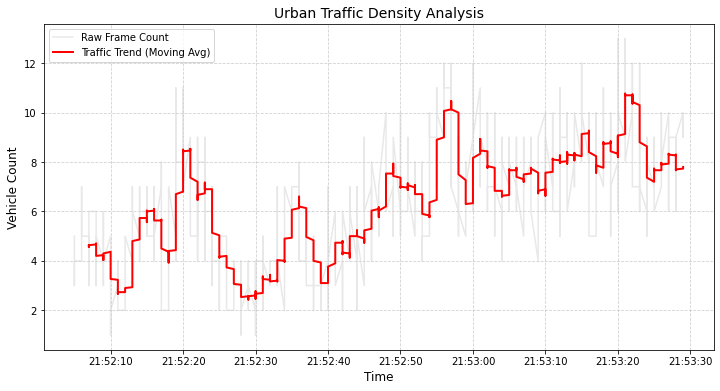

--- Traffic Analytics Summary ---
🚀 Peak Traffic Count: 13 vehicles
📉 Average Flow: 6.28 vehicles/frame
🕒 Total Monitoring Duration: 1613 samples


In [5]:
import cv2
import pandas as pd
from ultralytics import YOLO
import supervision as sv
from datetime import datetime
import matplotlib.pyplot as plt

# 1. Load Model
model = YOLO('yolov8n.pt')

# 2. Annotators
box_annotator = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator(text_thickness=2, text_scale=0.7)

# 3. Data Storage for Analytics
traffic_logs = []

def process_traffic():
    cap = cv2.VideoCapture("data/traffic_footage.mp4")
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        # Detection
        results = model(frame, classes=[2, 3, 5, 7], conf=0.5, iou=0.5, agnostic_nms=True)[0]
        detections = sv.Detections.from_ultralytics(results)
        
        # LOGGING: Record current time and number of detections
        current_time = datetime.now().strftime("%H:%M:%S")
        vehicle_count = len(detections)
        traffic_logs.append({"Time": current_time, "Density": vehicle_count})

        # Visualization logic
        labels = [f"{model.model.names[class_id]} {confidence:0.2f}"
                  for class_id, confidence in zip(detections.class_id, detections.confidence)]
        
        annotated_frame = box_annotator.annotate(scene=frame, detections=detections)
        annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=detections, labels=labels)

        cv2.imshow("Urban Traffic Vision", annotated_frame)
        if cv2.waitKey(1) & 0xFF == ord('q'): break

    cap.release()
    cv2.destroyAllWindows()
    
    # --- AFTER VIDEO ENDS: EXPORT & PLOT ---
    export_and_plot()

def export_and_plot():
    # 1. Create DataFrame
    df = pd.DataFrame(traffic_logs)
    df['Time'] = pd.to_datetime(df['Time']) # Convert to datetime objects
    
    # 2. SMOOTHING LOGIC: Calculate a Rolling Average
    # 'window=30' averages the last 30 frames to create a smooth curve
    df['Smooth_Density'] = df['Density'].rolling(window=30).mean()

    # 3. Create the Professional Chart
    plt.figure(figsize=(12, 6))
    
    # Plot the original data in light grey (optional)
    plt.plot(df['Time'], df['Density'], color='lightgray', alpha=0.5, label="Raw Frame Count")
    
    # Plot the smoothed trend line in bold red
    plt.plot(df['Time'], df['Smooth_Density'], color='red', linewidth=2, label="Traffic Trend (Moving Avg)")

    plt.title('Urban Traffic Density Analysis', fontsize=14)
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Vehicle Count', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.savefig('traffic_density_smooth.png')
    plt.show()
    
    peak_density = df['Density'].max()
    avg_density = df['Density'].mean()
    total_frames_monitored = len(df)

    print(f"--- Traffic Analytics Summary ---")
    print(f"🚀 Peak Traffic Count: {peak_density} vehicles")
    print(f"📉 Average Flow: {avg_density:.2f} vehicles/frame")
    print(f"🕒 Total Monitoring Duration: {total_frames_monitored} samples")

if __name__ == "__main__":
    process_traffic()